# Figures 8-9: exact non-Gaussian ($F_{\rm NL}^2$) correction

Reproduces `OGW_flat_fNL.pdf` (Fig. 8) and `OGW_lognormal_fNL.pdf`
(Fig. 9): the Gaussian spectrum plus the $F_{\rm NL}^2$ correction of
the Draft's non-Gaussianity appendix, at $A_\zeta=0.01$ and
$F_{\rm NL}=1,10$, evaluated exactly on both the QCD-crossover kernel
(`core/ng_kernels.py`, using `kernels_data_I1I2/`) and the exact-RD
kernel (closed form, kept inline below).

Results are cached in `../data/ng_cache_*.npz`; with the cache present
this notebook runs in seconds. Deleting a cache file forces a recompute
of that panel's $F_{\rm NL}^2$ quadrature, which takes ~15-30 min per
panel (110 nodes across both backgrounds).

In [1]:
import sys, os, glob, time
sys.path.insert(0, os.path.abspath("../core"))
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

import plotstyle; plotstyle.use_latex()
plt.rcParams.update({
    "font.size": 16, "axes.labelsize": 19, "axes.titlesize": 15,
    "legend.fontsize": 12, "xtick.labelsize": 15, "ytick.labelsize": 15,
})

import kernel as K
import spectra as sp
import background_qcd as qcd
import ng_kernels as ng

KDATA = os.path.abspath("../kernels_data")
KDATA_I1I2 = os.path.abspath("../kernels_data_I1I2")
CACHE_DIR = os.path.abspath("../data")
FIGDIR = os.path.abspath("../../Draft/Figures")

ETA_F = 0.5
NHZ_TO_HZ = 1e-9
A_ZETA = 0.01
FNL_LIST = [1.0, 10.0]
FNL_COLORS = {1.0: "C2", 10.0: "C1"}
OMEGA_R0_H2 = 4.2e-5

T_OBS_S = 16.0 * 365.25 * 24.0 * 3600.0
PTA_F_LO_HZ, PTA_F_HI_HZ = 1.0 / T_OBS_S, 20.0 / T_OBS_S

Y_RANGE_FLAT = (3e-10, 2e-7)
Y_RANGE_LOGNORMAL = (1e-24, 1e-3)
Y_RANGE_DEV = (-1.5, 3.0)


def add_pta_band(ax):
    ax.axvspan(PTA_F_LO_HZ, PTA_F_HI_HZ, color="0.85", zorder=0, lw=0)


def load_tables(stride=2):
    """Every `stride`-th tabulated k-node from kernels_data/ and
    kernels_data_I1I2/, paired by matching f_nHz."""
    files_i2 = sorted(glob.glob(os.path.join(KDATA, "kernel_f*.npz")),
                      key=lambda fn: float(np.load(fn)["f_nHz"]))[::stride]
    files_i12 = sorted(glob.glob(os.path.join(KDATA_I1I2, "kernel_I1I2_f*.npz")),
                       key=lambda fn: float(np.load(fn)["f_nHz"]))[::stride]
    tabs = [np.load(fn) for fn in files_i2]
    tabs_i1i2 = [np.load(fn) for fn in files_i12]
    f_nHz = np.array([float(t["f_nHz"]) for t in tabs])
    f_nHz_i12 = np.array([float(t["f_nHz"]) for t in tabs_i1i2])
    assert np.allclose(f_nHz, f_nHz_i12, rtol=1e-6), "kernels_data/kernels_data_I1I2 node mismatch"
    ks = np.array([float(t["k"]) for t in tabs])
    return tabs, tabs_i1i2, f_nHz, ks


def Ph_from_table(tab, pz, k):
    t, s, I2 = tab["t"], tab["s"], tab["I2bar"]
    T, S = np.meshgrid(t, s, indexing="ij")
    W = K.weight(T, S) * pz(k * K.u_of(T, S)) * pz(k * K.v_of(T, S))
    return 4.0 * trapezoid(trapezoid(W * I2, x=s, axis=1), x=t)


def omega_gaussian_qcd(tabs, ks, pz):
    Ph_tab = np.array([Ph_from_table(t, pz, k) for t, k in zip(tabs, ks)])
    return np.array([sp.omega_gw(float(k), p, qcd, ETA_F) for k, p in zip(ks, Ph_tab)])


def omega_fnl2_unit_qcd(tabs, tabs_i1i2, ks, pz):
    """Omega_GW^{F_NL^2}/F_NL^2 at each k, exact QCD kernel."""
    out = np.zeros(len(ks))
    for i, (tab, tab12, k) in enumerate(zip(tabs, tabs_i1i2, ks)):
        nk = ng.NodeKernels(tab, tab12)
        out[i] = ng.omega_gw_FNL2_unit(nk, float(k), pz, qcd, ETA_F)
    return out

background_qcd: solving coupled continuity-equation ODE for T(eta), a(eta) (g_rho, g_s, w from lattice_gstar.py)...
  norm = 1.0032620737


## Exact-RD $F_{\rm NL}^2$ kernel

Closed-form RD kernel, unaffected by the background, kept separate from `ng_kernels.py` (which is the exact-QCD leg).

In [2]:
def _rd_pieces(t, s):
    u, v = K.u_of(t, s), K.v_of(t, s)
    A = -5.0 + s**2 + t * (2.0 + t)
    IA = 3.0 * A / (8.0 * u**3 * v**3)
    logarg = np.abs((-2.0 + t * (2.0 + t)) / (3.0 - s**2))
    IB = -(1.0 - s + t) * (1.0 + s + t) + 0.5 * A * np.log(logarg)
    IC = 0.5 * A * np.heaviside(t - K.T_RESONANCE, 0.5)
    return IA, IB, IC


def _rd_I2bar_cross(t1, s1, t2, s2):
    IA1, IB1, IC1 = _rd_pieces(t1, s1)
    IA2, IB2, IC2 = _rd_pieces(t2, s2)
    return 0.5 * IA1 * IA2 * (IB1 * IB2 + np.pi**2 * IC1 * IC2)


def _rd_J2bar(t, s):
    return ng.Jfun(t, s)**2 * K.I2bar_rd_exact(t, s)


def P_h_FNL2_unit_rd(k, pz, n_t_seg=30, n_s=41, n_phi=28, t_min=2.0 * ng.IR_REG,
                     t_max=30.0, reg=ng.IR_REG, **_ignored):
    """Same quadrature as ng.P_h_FNL2_unit, exact-RD kernel throughout."""
    t1, s1, w1 = ng._ts_grid_flat(n_t_seg, n_s, t_min, t_max)
    u1, v1 = K.u_of(t1, s1), K.v_of(t1, s1)

    t1c, s1c, w1c = t1[:, None], s1[:, None], w1[:, None]
    u1c, v1c = u1[:, None], v1[:, None]
    t2r, s2r, w2r = t1[None, :], s1[None, :], w1[None, :]
    u2r, v2r = u1[None, :], v1[None, :]
    W2 = w1c * w2r

    J2_1 = _rd_J2bar(t1, s1)[:, None]
    hybrid = np.sum(
        J2_1 / np.clip(u1c * v1c * u2r * v2r, reg**2, None)**2
        * pz(k * v1c * v2r) * pz(k * u1c) * pz(k * v1c * u2r)
        * W2
    )

    JJ = ng.Jfun(t1, s1)[:, None] * ng.Jfun(t1, s1)[None, :] * _rd_I2bar_cross(t1c, s1c, t2r, s2r)
    phi = np.linspace(0.0, 2.0 * np.pi, n_phi, endpoint=False)
    dphi = 2.0 * np.pi / n_phi

    sqrt_A1A2, y_const = ng.y_pieces(t1c, s1c, t2r, s2r)
    pz_v2r, pz_u2r, pz_v1c = pz(k * v2r), pz(k * u2r), pz(k * v1c)
    JJ_t = JJ * pz_v2r / v2r**3 * pz_u2r / u2r**3
    JJ_u = JJ * pz_v1c / v1c**3 * pz_v2r / v2r**3

    term_t = 0.0
    term_u = 0.0
    for p in phi:
        cp = np.cos(2.0 * p)
        y = 0.25 * np.cos(p) * sqrt_A1A2 + y_const
        w12, wbar12 = ng._w_wbar_of_y(t1c, s1c, t2r, s2r, y, reg=reg)

        it = (cp / np.pi) * JJ_t * pz(k * w12) / w12**3
        term_t += dphi * np.sum(it * W2)

        iu = (cp / np.pi) * JJ_u * pz(k * wbar12) / wbar12**3
        term_u += dphi * np.sum(iu * W2)

    return 0.125 * (hybrid + term_t + term_u)


def omega_fnl2_unit_rd(ks, pz):
    out = np.zeros(len(ks))
    for i, k in enumerate(ks):
        Ph_u = P_h_FNL2_unit_rd(float(k), pz)
        out[i] = sp.omega_gw(float(k), Ph_u, qcd, ETA_F, eta_c=1.0 / float(k))
    return out


def omega_gaussian_rd(ks, spec):
    """Gaussian piece, exact-RD kernel, QCD-dilution rescaled."""
    Ph_rd = np.array([sp.Ph(float(k), spec, i2bar=K.I2bar_rd_exact, n_s=51, n_seg=100) for k in ks])
    return np.array([sp.omega_gw(float(k), p, qcd, ETA_F, eta_c=1.0 / float(k)) for k, p in zip(ks, Ph_rd)])


def total_curves(om_gauss_unit, om_fnl2_unit):
    curves = {"gaussian": OMEGA_R0_H2 * A_ZETA**2 * om_gauss_unit}
    for fnl in FNL_LIST:
        curves[fnl] = curves["gaussian"] + OMEGA_R0_H2 * A_ZETA**3 * fnl**2 * om_fnl2_unit
    return curves


def rd_curves(om_g_rd_phys, om_fnl2_unit_rd):
    curves = {"gaussian": om_g_rd_phys}
    for fnl in FNL_LIST:
        curves[fnl] = om_g_rd_phys + OMEGA_R0_H2 * A_ZETA**3 * fnl**2 * om_fnl2_unit_rd
    return curves


def deviation(curve, ref):
    """Plain fractional deviation curve/ref - 1, no peak-rescaling."""
    return curve / ref - 1.0

## Figure 8: flat spectrum

/var/folders/5s/jr4cw8rj7nzgq87s9cw7z8080000gn/T/ipykernel_70441/3721642065.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


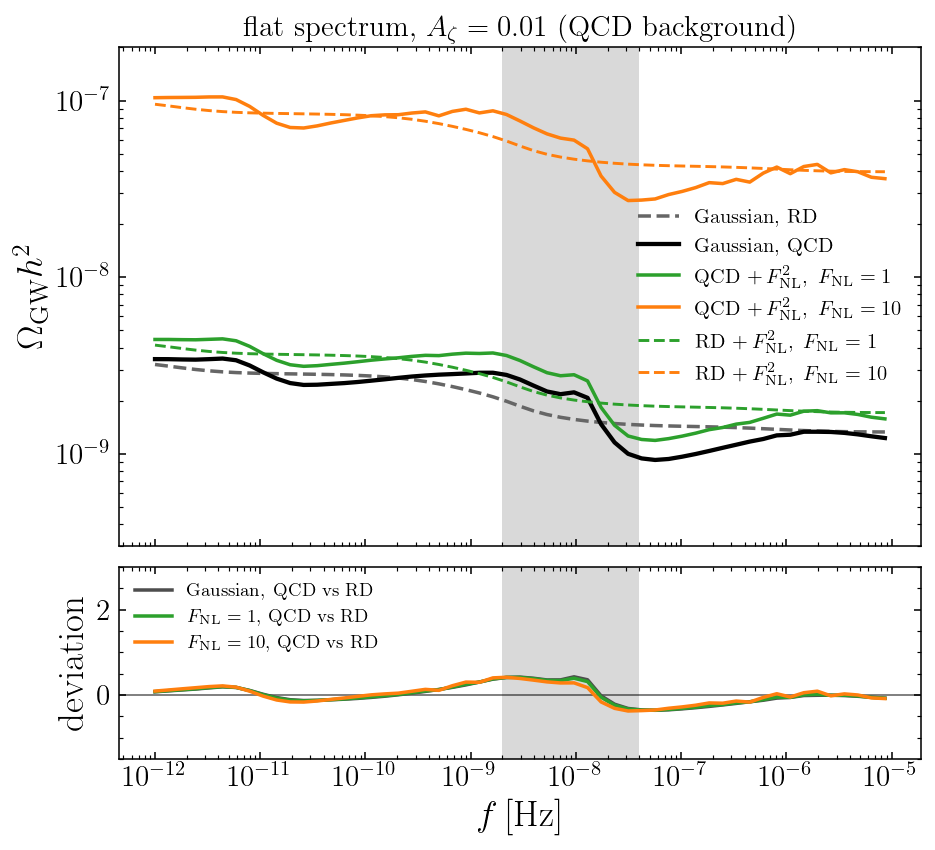

saved OGW_flat_fNL.pdf


In [3]:
cache = os.path.join(CACHE_DIR, "ng_cache_flat.npz")
if os.path.exists(cache):
    d = np.load(cache)
    f_nHz, om_g, om_f2, om_g_rd, om_f2_rd = (d["f_nHz"], d["om_g"], d["om_f2"],
                                               d["om_g_rd"], d["om_f2_rd"])
else:
    tabs, tabs_i1i2, f_nHz, ks = load_tables(stride=2)
    pz = sp.make_pzeta(("flat",))
    print("flat: Gaussian (QCD, tabulated)...")
    om_g = omega_gaussian_qcd(tabs, ks, pz)
    print("flat: Gaussian (RD, c_g-scaled)...")
    om_g_rd = omega_gaussian_rd(ks, ("flat",))
    print("flat: F_NL^2 unit (exact QCD)...")
    t0 = time.time()
    om_f2 = omega_fnl2_unit_qcd(tabs, tabs_i1i2, ks, pz)
    print(f"  done in {time.time()-t0:.1f}s")
    print("flat: F_NL^2 unit (exact RD)...")
    t0 = time.time()
    om_f2_rd = omega_fnl2_unit_rd(ks, pz)
    print(f"  done in {time.time()-t0:.1f}s")
    np.savez(cache, f_nHz=f_nHz, om_g=om_g, om_f2=om_f2, om_g_rd=om_g_rd, om_f2_rd=om_f2_rd)

curves = total_curves(om_g, om_f2)
f_Hz = f_nHz * NHZ_TO_HZ
om_g_rd_phys = OMEGA_R0_H2 * A_ZETA**2 * om_g_rd
rd_fnl = rd_curves(om_g_rd_phys, om_f2_rd)

fig, (axt, axb) = plt.subplots(2, 1, figsize=(7.4, 6.6), sharex=True,
                               gridspec_kw={"height_ratios": [2.6, 1.0], "hspace": 0.06})
add_pta_band(axt)
axt.loglog(f_Hz, om_g_rd_phys, "--", lw=1.8, color="0.4", label=r"Gaussian, RD")
axt.loglog(f_Hz, curves["gaussian"], "-", lw=2.2, color="k", label=r"Gaussian, QCD")
for fnl in FNL_LIST:
    axt.loglog(f_Hz, curves[fnl], "-", lw=1.8, color=FNL_COLORS[fnl],
              label=rf"QCD $+\,F_{{\rm NL}}^2,\ F_{{\rm NL}}={int(fnl)}$")
for fnl in FNL_LIST:
    axt.loglog(f_Hz, rd_fnl[fnl], "--", lw=1.5, color=FNL_COLORS[fnl],
              label=rf"RD $+\,F_{{\rm NL}}^2,\ F_{{\rm NL}}={int(fnl)}$")
axt.set_ylabel(r"$\Omega_{\rm GW}h^2$")
axt.set_ylim(*Y_RANGE_FLAT)
axt.legend(loc="best", fontsize=10.5)
axt.set_title(r"flat spectrum, $A_\zeta=0.01$ (QCD background)")
axt.tick_params(labelbottom=False)

add_pta_band(axb)
axb.axhline(0.0, color="k", lw=1.0, alpha=0.5)
axb.plot(f_Hz, deviation(curves["gaussian"], om_g_rd_phys), "-", lw=1.8,
        color="0.3", label=r"Gaussian, QCD vs RD")
axb.plot(f_Hz, deviation(curves[1.0], rd_fnl[1.0]), "-", lw=1.8,
        color=FNL_COLORS[1.0], label=r"$F_{\rm NL}=1$, QCD vs RD")
axb.plot(f_Hz, deviation(curves[10.0], rd_fnl[10.0]), "-", lw=1.8,
        color=FNL_COLORS[10.0], label=r"$F_{\rm NL}=10$, QCD vs RD")
axb.set_xscale("log")
axb.set_ylim(*Y_RANGE_DEV)
axb.set_xlabel(r"$f\,[\mathrm{Hz}]$")
axb.set_ylabel(r"deviation")
axb.legend(loc="upper left", fontsize=9.5, frameon=False)

fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "OGW_flat_fNL.pdf"))
plt.show()
print("saved OGW_flat_fNL.pdf")

## Figure 9: lognormal spectra, three peak frequencies

/var/folders/5s/jr4cw8rj7nzgq87s9cw7z8080000gn/T/ipykernel_70441/1716523023.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


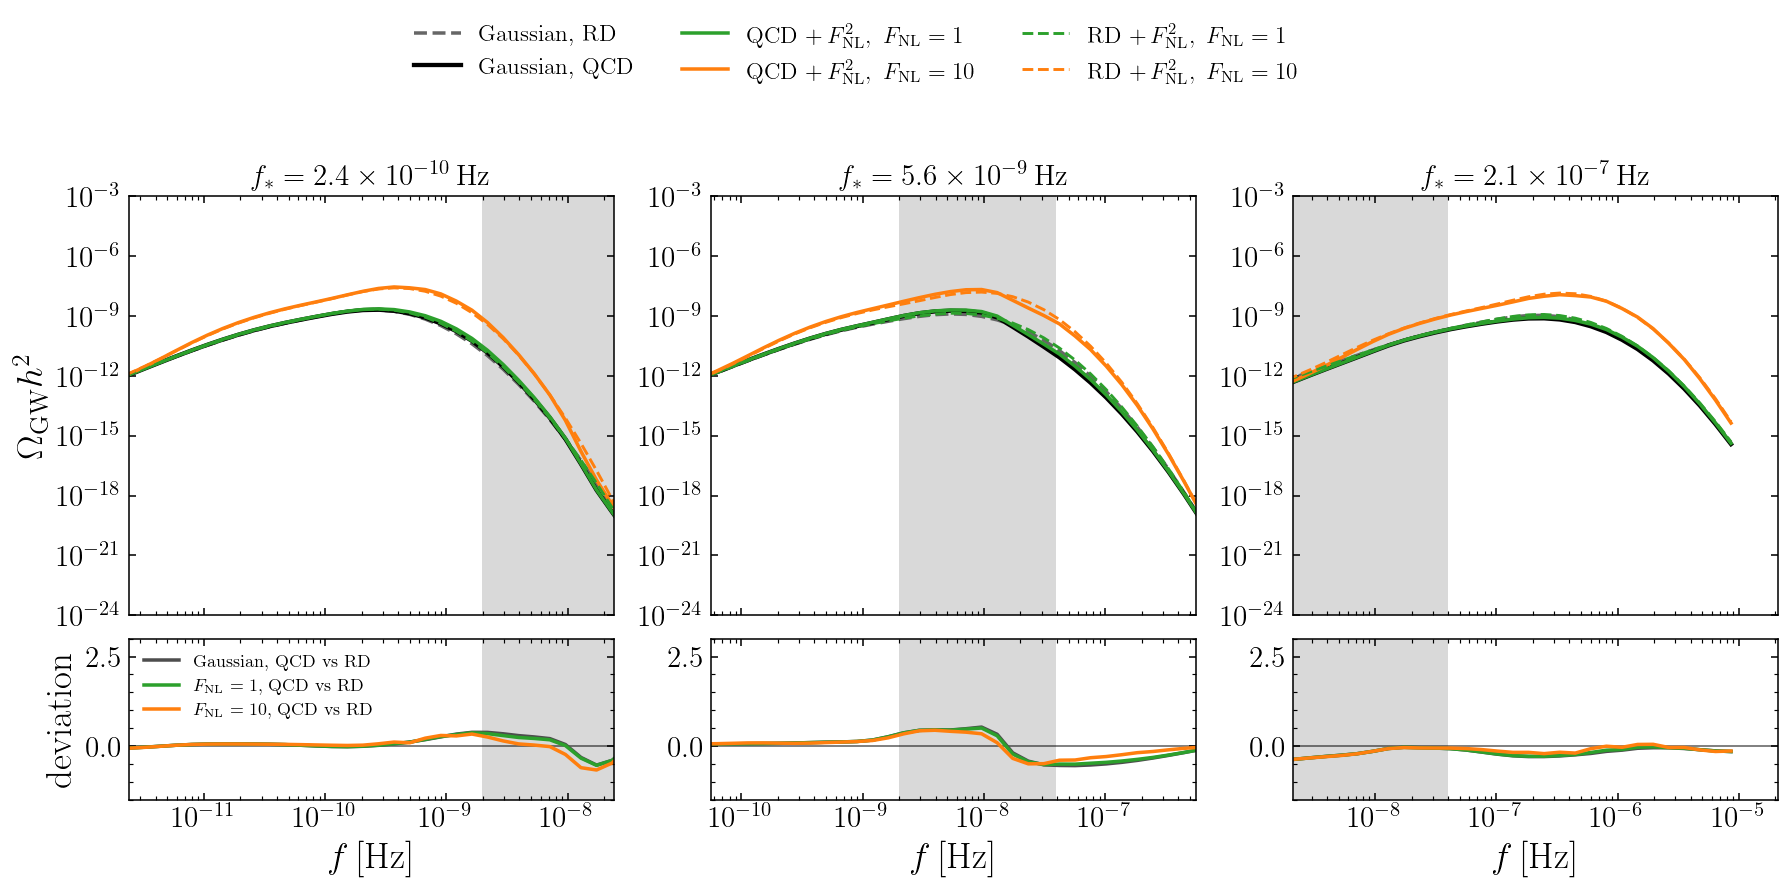

saved OGW_lognormal_fNL.pdf


In [4]:
sigma = 0.4
fstars_nHz = [0.24, 5.6, 210.0]

results = []
for fstar_nHz in fstars_nHz:
    cache = os.path.join(CACHE_DIR, f"ng_cache_lognormal_{fstar_nHz}.npz")
    if os.path.exists(cache):
        d = np.load(cache)
        results.append((fstar_nHz, d["f_nHz"], d["om_g_qcd"], d["om_g_rd"],
                       d["om_f2"], d["om_f2_rd"]))
        continue
    tabs, tabs_i1i2, f_nHz_nodes, ks_nodes = load_tables(stride=2)
    kstar = float(sp.f_Hz_to_k(np.array([fstar_nHz * 1e-9]))[0])
    pz = sp.make_pzeta(("lognormal", kstar, sigma))
    print(f"lognormal f*={fstar_nHz} nHz: Gaussian QCD (tabulated)...")
    om_g_qcd = omega_gaussian_qcd(tabs, ks_nodes, pz)
    print(f"lognormal f*={fstar_nHz} nHz: Gaussian RD (c_g-scaled)...")
    om_g_rd = omega_gaussian_rd(ks_nodes, ("lognormal", kstar, sigma))
    print(f"lognormal f*={fstar_nHz} nHz: F_NL^2 unit (exact QCD)...")
    t0 = time.time()
    om_f2 = omega_fnl2_unit_qcd(tabs, tabs_i1i2, ks_nodes, pz)
    print(f"  done in {time.time()-t0:.1f}s")
    print(f"lognormal f*={fstar_nHz} nHz: F_NL^2 unit (exact RD)...")
    t0 = time.time()
    om_f2_rd = omega_fnl2_unit_rd(ks_nodes, pz)
    print(f"  done in {time.time()-t0:.1f}s")
    np.savez(cache, f_nHz=f_nHz_nodes, om_g_qcd=om_g_qcd, om_g_rd=om_g_rd,
             om_f2=om_f2, om_f2_rd=om_f2_rd)
    results.append((fstar_nHz, f_nHz_nodes, om_g_qcd, om_g_rd, om_f2, om_f2_rd))

fig, axes = plt.subplots(2, 3, figsize=(15.2, 5.6), sharex="col",
                         gridspec_kw={"height_ratios": [2.6, 1.0], "hspace": 0.08})
for col, (fstar_nHz, f_nHz_nodes, om_g_qcd, om_g_rd, om_f2, om_f2_rd) in enumerate(results):
    axt, axb = axes[0, col], axes[1, col]
    curves = total_curves(om_g_qcd, om_f2)
    f_Hz = f_nHz_nodes * NHZ_TO_HZ
    om_g_rd_phys = OMEGA_R0_H2 * A_ZETA**2 * om_g_rd
    rd_fnl = rd_curves(om_g_rd_phys, om_f2_rd)

    axt.loglog(f_Hz, om_g_rd_phys, "--", lw=1.8, color="0.4", label=r"Gaussian, RD")
    axt.loglog(f_Hz, curves["gaussian"], "-", lw=2.2, color="k", label=r"Gaussian, QCD")
    for fnl in FNL_LIST:
        axt.loglog(f_Hz, curves[fnl], "-", lw=1.8, color=FNL_COLORS[fnl],
                  label=rf"QCD $+\,F_{{\rm NL}}^2,\ F_{{\rm NL}}={int(fnl)}$")
    for fnl in FNL_LIST:
        axt.loglog(f_Hz, rd_fnl[fnl], "--", lw=1.5, color=FNL_COLORS[fnl],
                  label=rf"RD $+\,F_{{\rm NL}}^2,\ F_{{\rm NL}}={int(fnl)}$")
    add_pta_band(axt)
    axt.set_xlim(fstar_nHz * 1e-9 * 1e-2, fstar_nHz * 1e-9 * 1e2)
    axt.set_ylim(*Y_RANGE_LOGNORMAL)
    fstar_Hz = fstar_nHz * 1e-9
    expo = int(np.floor(np.log10(fstar_Hz)))
    mant = fstar_Hz / 10.0**expo
    axt.set_title(rf"$f_\ast={mant:.1f}\times10^{{{expo}}}\,$Hz")
    axt.tick_params(labelbottom=False)

    add_pta_band(axb)
    axb.axhline(0.0, color="k", lw=1.0, alpha=0.5)
    axb.plot(f_Hz, deviation(curves["gaussian"], om_g_rd_phys), "-", lw=1.8,
            color="0.3", label=r"Gaussian, QCD vs RD")
    axb.plot(f_Hz, deviation(curves[1.0], rd_fnl[1.0]), "-", lw=1.8,
            color=FNL_COLORS[1.0], label=r"$F_{\rm NL}=1$, QCD vs RD")
    axb.plot(f_Hz, deviation(curves[10.0], rd_fnl[10.0]), "-", lw=1.8,
            color=FNL_COLORS[10.0], label=r"$F_{\rm NL}=10$, QCD vs RD")
    axb.set_xscale("log")
    axb.set_ylim(*Y_RANGE_DEV)
    axb.set_xlabel(r"$f\,[\mathrm{Hz}]$")

axes[0, 0].set_ylabel(r"$\Omega_{\rm GW}h^2$")
axes[1, 0].set_ylabel(r"deviation")
axes[0, 0].legend(loc="lower center", bbox_to_anchor=(1.5, 1.22), ncol=3, fontsize=12, frameon=False)
axes[1, 0].legend(loc="upper left", fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "OGW_lognormal_fNL.pdf"), bbox_inches="tight")
plt.show()
print("saved OGW_lognormal_fNL.pdf")